<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4431 entries, 0 to 4430
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4431 non-null   object 
 1   Open       4431 non-null   float64
 2   High       4431 non-null   float64
 3   Low        4431 non-null   float64
 4   Close      4431 non-null   float64
 5   Adj Close  4431 non-null   float64
 6   Volume     4431 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 242.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4431 entries, 0 to 4430
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4431 non-null   object 
 1   Open       4431 non-null   float64
 2   High       4431 non-null   float64
 3   Low        4431 non-null   float64
 4   Close      4431 non-null   float64
 5   Adj Close  4431 non-null   float64
 6   Volume     4431 non-null   int64  
dtyp

C:\Users\DELL-PC\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
35/35 - 11s - 324ms/step - loss: 4.2670e-04
Epoch 2/20
35/35 - 5s - 155ms/step - loss: 7.4655e-05
Epoch 3/20
35/35 - 5s - 153ms/step - loss: 6.0829e-05
Epoch 4/20
35/35 - 8s - 234ms/step - loss: 5.0154e-05
Epoch 5/20
35/35 - 7s - 197ms/step - loss: 5.2106e-05
Epoch 6/20
35/35 - 6s - 173ms/step - loss: 4.6641e-05
Epoch 7/20
35/35 - 6s - 160ms/step - loss: 3.3363e-05
Epoch 8/20
35/35 - 6s - 162ms/step - loss: 4.7380e-05
Epoch 9/20
35/35 - 6s - 163ms/step - loss: 3.8097e-05
Epoch 10/20
35/35 - 6s - 160ms/step - loss: 1.1794e-04
Epoch 11/20
35/35 - 5s - 153ms/step - loss: 4.1986e-05
Epoch 12/20
35/35 - 6s - 160ms/step - loss: 3.3918e-05
Epoch 13/20
35/35 - 6s - 172ms/step - loss: 4.0871e-05
Epoch 14/20
35/35 - 6s - 160ms/step - loss: 3.5797e-05
Epoch 15/20
35/35 - 6s - 168ms/step - loss: 3.0956e-05
Epoch 16/20
35/35 - 5s - 149ms/step - loss: 3.5910e-05
Epoch 17/20
35/35 - 6s - 164ms/step - loss: 2.6907e-05
Epoch 18/20
35/35 - 6s - 165ms/step - loss: 2.3075e-05
Epoch 19/20
35/35 

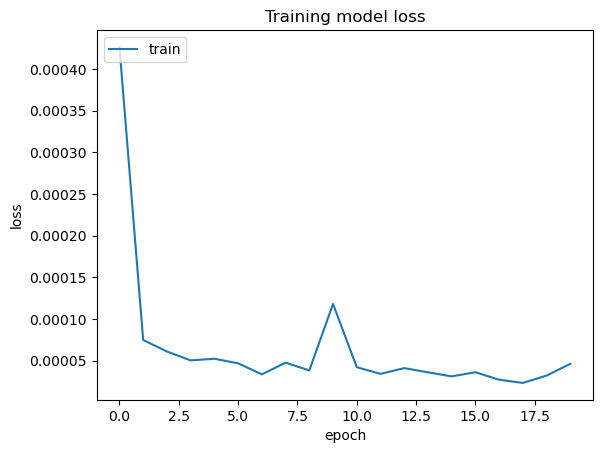

(4371, 60, 1)
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step


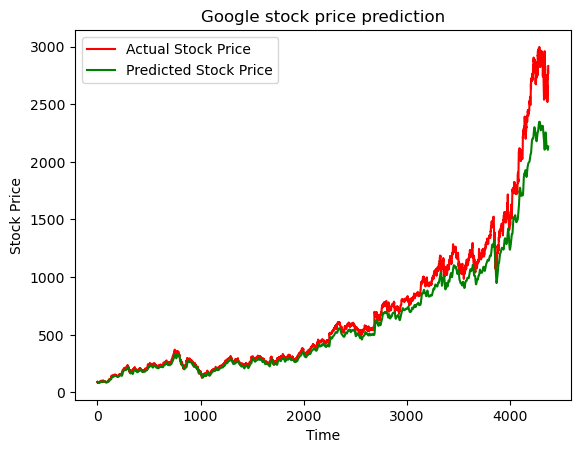

In [1]:
# Statement:Use the Google stock prices dataset and design a time series
# analysis and prediction system using RNN.
# To study and understand Recurrent Neural Network by doing analysis and
# designing prediction systems.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout
#Load Dataset
data = pd.read_csv('C:/Users/DELL-PC/DL/GOOGL.csv')
data.head()
#Dataset Information
data.info()
#Convert Close Price to Numeric
data["Close"]=pd.to_numeric(data.Close,errors='coerce')
data = data.dropna()
#7. Select Close Column -Close stock price column
trainData = data.iloc[:,4:5].values
#Dataset Information
data.info()
#Normalize Data
sc = MinMaxScaler(feature_range=(0,1))
trainData = sc.fit_transform(trainData)
trainData.shape
#Create Training Sequences
X_train = []
y_train = []

for i in range(60, 1149):  # 60 = timestep
    X_train.append(trainData[i-60:i, 0])
    y_train.append(trainData[i, 0])
#Convert to Arrays NumPy arrays
X_train, y_train = np.array(X_train), np.array(y_train)
#Reshape Data
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1)) #adding the batch_siz
X_train.shape
#Create LSTM Model
model = Sequential()
model.add(LSTM(units=100, return_sequences = True, input_shape =(X_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences = False))
model.add(Dropout(0.2))
model.add(Dense(units =1))
model.compile(optimizer='adam',loss="mean_squared_error")
#Train Model
hist = model.fit(X_train, y_train, epochs = 20, batch_size = 32, verbose=2)
#Plot Loss Graph
plt.plot(hist.history['loss'])
plt.title('Training model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()
#
data["Close"] = pd.to_numeric(data["Close"], errors='coerce')

# Drop NaN values
data = data.dropna()

# Select Close column
data = data.iloc[:, 4:5]

# Create y_test
y_test = data.iloc[60:, 0:].values

# Prepare input for model
inputClosing = data.iloc[:, 0:].values
inputClosing_scaled = sc.transform(inputClosing)

# Create X_test
X_test = []
timestep = 60
length = len(data)

for i in range(timestep, length):
    X_test.append(inputClosing_scaled[i - timestep:i, 0])

X_test = np.array(X_test)

# Reshape for LSTM (3D)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(X_test.shape)
#
y_pred = model.predict(X_test)
y_pred
#
predicted_price = sc.inverse_transform(y_pred)
#
plt.plot(y_test, color = 'red', label = 'Actual Stock Price')
plt.plot(predicted_price, color = 'green', label = 'Predicted Stock Price')
plt.title('Google stock price prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()